
# 商品分析｜商品組合與定價調整

商業問題：  
品類與品牌營收貢獻排名  
分析方法：  
- 整合銷售與商品資料
- 依品類彙總營收並計算營收占比
- 依營收排序，比較品類的營收貢獻

In [ ]:
import pandas as pd
sales=pd.read_csv("sales.csv")
products=pd.read_csv("products.csv")
df=pd.merge(sales,products, on="Product_ID")
cat_revenue=df.groupby("Category")["Order_Value"].sum().reset_index()
total_revenue=cat_revenue["Order_Value"].sum()
cat_revenue["營收占比(%)"]=(cat_revenue["Order_Value"]/total_revenue*100).round(2)
result=cat_revenue.sort_values(by="Order_Value", ascending=False).reset_index(drop=True)
result.columns=["品類","總營收","營收占比(%)"]
print(result)

            品類           總營收  營收占比(%)
0  Electronics  4.351116e+09    72.62
1         Home  7.237047e+08    12.08
2       Sports  4.808234e+08     8.02
3      Fashion  3.372601e+08     5.63
4      Grocery  4.180921e+07     0.70
5       Beauty  3.866905e+07     0.65
6        Books  1.858356e+07     0.31


分析結果：  
Electronics 以 72.62% 的營收占比一枝獨秀，遠超其他品類，是最主要的營收來源。 Home （ 12.08% ）與 Sports （ 8.02% ）合計約占兩成，屬次要貢獻來源。 Fashion 僅 5.63% ，而 Grocery、Beauty、Books 三者合計不到 2% ，顯示營收結構高度集中於少數品類，其他品類的營收貢獻相對有限。

商業問題：  
折扣深度與銷售表現關聯分析  
分析方法：  
- 彙總各商品的總銷售量
- 計算折扣幅度與銷售量的相關係數
- 以散佈圖與趨勢線觀察兩者的關聯

相關係數 (Correlation): 0.0204


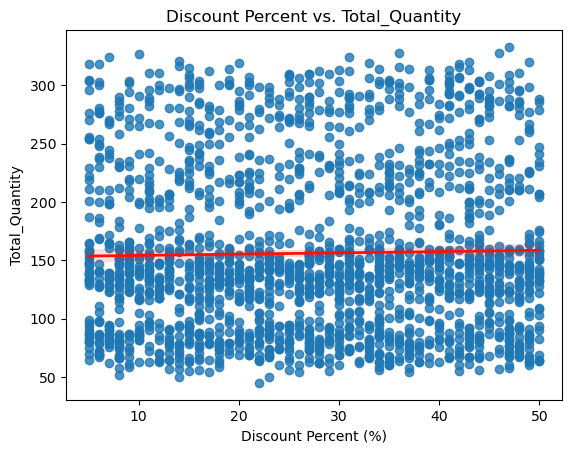

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sales=pd.read_csv("sales.csv")
products=pd.read_csv("products.csv")
sales_agg=sales.groupby('Product_ID')['Quantity'].sum().reset_index()
sales_agg.rename(columns={"Quantity":"Total_Quantity"}, inplace=True)
df_1=products.merge(sales_agg, on="Product_ID",how="inner")
corr=df_1["Discount_Percent"].corr(df_1["Total_Quantity"])
print(f"相關係數 (Correlation): {corr:.4f}")
sns.regplot(
    data=df_1, 
    x="Discount_Percent", 
    y="Total_Quantity",
    line_kws={"color": "#f5130c", "linewidth": 2})
plt.title("Discount Percent vs. Total_Quantity")
plt.xlabel("Discount Percent (%)")
plt.ylabel("Total_Quantity")
plt.show()

分析結果：  
折扣百分比與商品總訂單量的相關係數為 0.0204，接近 0，顯示兩者幾乎沒有線性關聯。散佈圖中的商品銷售量也未呈現明顯的線性上升或下降趨勢，代表在商品層級下，折扣幅度較高的商品並不一定具有較高的總銷售量。

商業問題：  
商品評價與銷售表現關聯分析  
分析方法：  
- 彙總各商品的總訂單量
- 計算商品評價與訂單量的中位數
- 以中位數建立四象限，區分明星、潛力、高風險與滯銷商品

In [24]:
import pandas as pd
products=pd.read_csv("products.csv")
sales=pd.read_csv("sales.csv")
sales_agg_1=sales.groupby("Product_ID")["Quantity"].sum().reset_index()
sales_agg_1.rename(columns={'Quantity': 'Total_Quantity'}, inplace=True)
df_2=pd.merge(products[["Product_ID","Avg_Rating"]],sales_agg_1,on="Product_ID",how="inner")
median_rating=df_2["Avg_Rating"].median()
median_quantity=df_2["Total_Quantity"].median()
def classify_quadrant(row):
    high_rating=row["Avg_Rating"] >= median_rating
    high_quantity=row["Total_Quantity"] >= median_quantity
    if high_rating and high_quantity:
        return "高評價高銷量"
    elif high_rating and not high_quantity:
        return "高評價低銷量"
    elif not high_rating and high_quantity:
        return "低評價高銷量"
    else:
        return "低評價低銷量"
df_2["Quadrant"]=df_2.apply(classify_quadrant, axis=1)
print("評價中位數：",median_rating)
print("訂單中位數：",median_quantity)
print(df_2["Quadrant"].value_counts())

評價中位數： 4.4
訂單中位數： 141.0
Quadrant
高評價高銷量    549
高評價低銷量    523
低評價低銷量    468
低評價高銷量    460
Name: count, dtype: int64


分析結果：  
以商品評價與總訂單量的中位數（分別為 4.4 分與 141 件）建立四象限， 2,000 項商品分布於四個區域，其中高評價高銷量商品 549 項、高評價低銷量商品 523 項、低評價高銷量商品 460 項、低評價低銷量商品 468 項。四類商品的數量差距不大，顯示高評價並不一定對應高訂單量，低評價商品也可能具有較高的銷售量，商品評價與訂單量之間的關係並不單純。

商業問題：  
庫存去化速度與滯銷風險分析   
分析方法：  
- 彙總商品銷量，計算日均銷量
- 依庫存量與日均銷量估算售罄天數
- 篩選售罄天數超過 1,000 天的商品

In [29]:
import pandas as pd
sales=pd.read_csv("sales.csv")
products=pd.read_csv("products.csv")
sales["Order_Date"]=pd.to_datetime(sales["Order_Date"],format="%d/%m/%Y")
total_days=(sales["Order_Date"].max() - sales["Order_Date"].min()).days+1
sales_agg_2=sales.groupby("Product_ID")["Quantity"].sum().reset_index()
sales_agg_2.rename(columns={"Quantity":"Total_Quantity"},inplace=True)
df_3=pd.merge(products[["Product_ID","Product_Name","Stock_Quantity"]],sales_agg_2,on="Product_ID",how="left")
df_3["Total_Quantity"] = df_3["Total_Quantity"].fillna(0)
df_3["Daily_Sales"]=df_3["Total_Quantity"]/total_days
df_3["Days_to_Sell"] = df_3["Stock_Quantity"] / df_3["Daily_Sales"]
long_days_products=df_3[df_3["Days_to_Sell"]>1000].sort_values(by="Days_to_Sell", ascending=False)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(long_days_products)

      Product_ID         Product_Name  Stock_Quantity  Total_Quantity  Daily_Sales  Days_to_Sell
264   PROD000265        Plum Serum V1             956              57     0.075000  12746.666667
1555  PROD001556    Lakme Lipstick V7             933              56     0.073684  12662.142857
122   PROD000123      Nivea Cream V10             995              62     0.081579  12196.774194
1590  PROD001591    Lakme Lipstick V8             832              52     0.068421  12160.000000
614   PROD000615        Plum Serum V3             968              62     0.081579  11865.806452
...          ...                  ...             ...             ...          ...           ...
116   PROD000117   Prestige Cooker V8             228             170     0.223684   1019.294118
1043  PROD001044          Notebook V9             118              88     0.115789   1019.090909
1757  PROD001758        Nike Shoes V7             323             241     0.317105   1018.589212
1504  PROD001505  Haldiram Sna

分析結果：  
以 2,000 項商品的歷史平均每日銷量估算目前庫存的預估售罄天數，並篩選超過 1,000 天的商品。結果共有 1,590 項商品超過此門檻，顯示多數商品的庫存相較於歷史銷售速度偏高，單以 1,000 天作為固定門檻難以有效區分不同程度的庫存去化效率。因此，與其直接將超過 1,000 天的商品視為滯銷商品，更適合進一步依品類或其他商品特徵分層比較，找出真正具有較長售罄天數的商品。